In [1]:
#imports 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [2]:
df=pd.read_csv("road_network.csv")
print(df.index)
print("All columns are")
ai=0
for i in df:
    print(ai,i)
    ai+=1

RangeIndex(start=0, stop=200, step=1)
All columns are
0 road_id
1 road_name
2 road_type
3 length_km
4 lanes
5 speed_limit_kmh
6 capacity_vehicles_per_hour
7 has_bus_lane
8 has_bike_lane
9 surface_condition
10 last_maintenance_date
11 latitude_start
12 longitude_start
13 latitude_end
14 longitude_end
15 district
16 toll_rate_rp
17 avg_daily_traffic


In [3]:
df.shape

(200, 18)

In [4]:
df.head(n=10)

,road_id,road_name,road_type,length_km,lanes,speed_limit_kmh,capacity_vehicles_per_hour,has_bus_lane,has_bike_lane,surface_condition,last_maintenance_date,latitude_start,longitude_start,latitude_end,longitude_end,district,toll_rate_rp,avg_daily_traffic
0,RD-0001,Jl. Segment 1,Jalan Kolektor,4.3,4,60,5384,0,0,Cukup,2022-12-21,-6.173938,106.920654,-6.187271,106.937674,PIK,0,10833
1,RD-0002,Jl. Segment 2,Jalan Arteri,4.3,4,80,6132,0,0,Baik,2022-11-17,-6.248396,106.768647,-6.246220,106.771962,Depok,0,6921
2,RD-0003,Jl. Segment 3,Jalan Lokal,1.8,2,40,978,0,0,Cukup,2023-04-15,-6.267631,106.814963,-6.264098,106.831007,Tangerang,0,1085
3,RD-0004,Jl. Segment 4,Jalan Kolektor,1.8,4,60,4160,0,1,Rusak Berat,2022-05-17,-6.112216,106.954036,-6.122268,106.958261,Mangga Dua,0,6145
4,RD-0005,Jl. Segment 5,Jalan Tol,22.7,4,80,6600,1,0,Baik,2024-02-16,-6.349760,106.861835,-6.341074,106.856648,Sudirman,7000,8023
5,RD-0006,Jl. Segment 6,Jalan Lingkungan,1.4,1,40,404,0,1,Rusak Ringan,2022-07-22,-6.210781,106.961270,-6.224882,106.955449,Senayan,0,474
6,RD-0007,Jl. Segment 7,Jalan Lokal,1.0,2,20,1318,0,0,Cukup,2023-02-19,-6.313205,106.892955,-6.306143,106.886125,Menteng,0,2133
7,RD-0008,Jl. Segment 8,Jalan Lokal,2.1,2,30,828,0,1,Cukup,2022-08-01,-6.189440,106.825046,-6.180580,106.833229,PIK,0,900
8,RD-0009,Jl. Segment 9,Jalan Tol,18.9,8,80,13272,1,0,Baik,2022-07-26,-6.303765,106.787068,-6.298471,106.802574,Kelapa Gading,15000,12171
9,RD-0010,Jl. Segment 10,Jalan Lingkungan,2.7,1,30,553,0,1,Baik,2022-09-10,-6.160512,106.968443,-6.148262,106.965690,PIK,0,738


In [5]:
df.sample(n=10)

,road_id,road_name,road_type,length_km,lanes,speed_limit_kmh,capacity_vehicles_per_hour,has_bus_lane,has_bike_lane,surface_condition,last_maintenance_date,latitude_start,longitude_start,latitude_end,longitude_end,district,toll_rate_rp,avg_daily_traffic
181,RD-0182,Jl. Segment 182,Jalan Lingkungan,1.7,1,20,681,0,1,Rusak Berat,2024-01-31,-6.104177,106.764650,-6.103834,106.773412,PIK,0,1203
165,RD-0166,Jl. Segment 166,Jalan Lingkungan,2.4,1,40,781,0,0,Rusak Ringan,2024-01-27,-6.285120,106.733146,-6.284932,106.741688,Grogol,0,586
138,RD-0139,Jl. Segment 139,Jalan Kolektor,3.2,4,50,5824,0,0,Cukup,2022-09-26,-6.228993,106.957449,-6.217234,106.953323,PIK,0,9552
145,RD-0146,Jl. Segment 146,Jalan Kolektor,3.9,2,50,2960,0,1,Baik,2022-09-08,-6.272970,106.939569,-6.274926,106.923302,Mangga Dua,0,3778
37,RD-0038,Jl. Segment 38,Jalan Tol,13.4,4,100,6060,1,0,Cukup,2024-01-14,-6.255654,106.865781,-6.267243,106.868851,Slipi,15000,6540
193,RD-0194,Jl. Segment 194,Jalan Arteri,9.7,6,80,10476,1,0,Baik,2023-07-15,-6.223036,106.759054,-6.214148,106.753365,Mangga Dua,0,20287
60,RD-0061,Jl. Segment 61,Jalan Lokal,1.0,1,40,748,0,1,Cukup,2022-05-25,-6.119442,106.741716,-6.099976,106.730684,Kuningan,0,784
27,RD-0028,Jl. Segment 28,Jalan Kolektor,4.5,4,50,4316,0,0,Baik,2022-10-08,-6.157486,106.795632,-6.173350,106.814874,Mangga Dua,0,4040
89,RD-0090,Jl. Segment 90,Jalan Lingkungan,2.2,1,20,536,0,0,Baik,2023-07-12,-6.241755,106.990858,-6.228970,107.008155,Depok,0,533
10,RD-0011,Jl. Segment 11,Jalan Lokal,2.6,1,20,566,0,0,Baik,2022-08-10,-6.229897,106.715647,-6.215547,106.710705,Menteng,0,594


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   road_id                     200 non-null    object 
 1   road_name                   200 non-null    object 
 2   road_type                   200 non-null    object 
 3   length_km                   200 non-null    float64
 4   lanes                       200 non-null    int64  
 5   speed_limit_kmh             200 non-null    int64  
 6   capacity_vehicles_per_hour  200 non-null    int64  
 7   has_bus_lane                200 non-null    int64  
 8   has_bike_lane               200 non-null    int64  
 9   surface_condition           200 non-null    object 
 10  last_maintenance_date       200 non-null    object 
 11  latitude_start              200 non-null    float64
 12  longitude_start             200 non-null    float64
 13  latitude_end                200 non

In [7]:
df.isnull()

,road_id,road_name,road_type,length_km,lanes,speed_limit_kmh,capacity_vehicles_per_hour,has_bus_lane,has_bike_lane,surface_condition,last_maintenance_date,latitude_start,longitude_start,latitude_end,longitude_end,district,toll_rate_rp,avg_daily_traffic
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
196,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
197,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
198,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [17]:
print(df.isnull().sum())
print('no null values')

road_id                       0
road_name                     0
road_type                     0
length_km                     0
lanes                         0
speed_limit_kmh               0
capacity_vehicles_per_hour    0
has_bus_lane                  0
has_bike_lane                 0
surface_condition             0
last_maintenance_date         0
latitude_start                0
longitude_start               0
latitude_end                  0
longitude_end                 0
district                      0
toll_rate_rp                  0
avg_daily_traffic             0
dtype: int64
no null values


In [9]:
df.describe()

,length_km,lanes,speed_limit_kmh,capacity_vehicles_per_hour,has_bus_lane,has_bike_lane,latitude_start,longitude_start,latitude_end,longitude_end,toll_rate_rp,avg_daily_traffic
count,200.00000,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,5.99450,3.335000,57.200000,4559.49000,0.190000,0.395000,-6.222513,106.858006,-6.221939,106.859040,3050.000000,5497.510000
std,6.07204,2.089162,29.161825,4157.73614,0.393285,0.490077,0.071297,0.082616,0.073120,0.082277,6461.910043,5264.646678
min,0.30000,1.000000,20.000000,404.00000,0.000000,0.000000,-6.349760,106.703131,-6.363767,106.692182,0.000000,353.000000
25%,1.90000,2.000000,40.000000,982.50000,0.000000,0.000000,-6.275835,106.792370,-6.278966,106.794568,0.000000,1167.750000
50%,3.05000,3.000000,50.000000,3112.00000,0.000000,0.000000,-6.227666,106.862516,-6.221347,106.864975,0.000000,3675.000000
75%,8.35000,4.000000,80.000000,6765.00000,0.000000,1.000000,-6.159397,106.922157,-6.163668,106.921874,0.000000,8847.250000
max,24.10000,8.000000,120.000000,15976.00000,1.000000,1.000000,-6.101649,106.998380,-6.087672,107.011265,25000.000000,28394.000000


In [10]:
# Removing null values
df = df.dropna()
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   road_id                     200 non-null    object 
 1   road_name                   200 non-null    object 
 2   road_type                   200 non-null    object 
 3   length_km                   200 non-null    float64
 4   lanes                       200 non-null    int64  
 5   speed_limit_kmh             200 non-null    int64  
 6   capacity_vehicles_per_hour  200 non-null    int64  
 7   has_bus_lane                200 non-null    int64  
 8   has_bike_lane               200 non-null    int64  
 9   surface_condition           200 non-null    object 
 10  last_maintenance_date       200 non-null    object 
 11  latitude_start              200 non-null    float64
 12  longitude_start             200 non-null    float64
 13  latitude_end                200 non

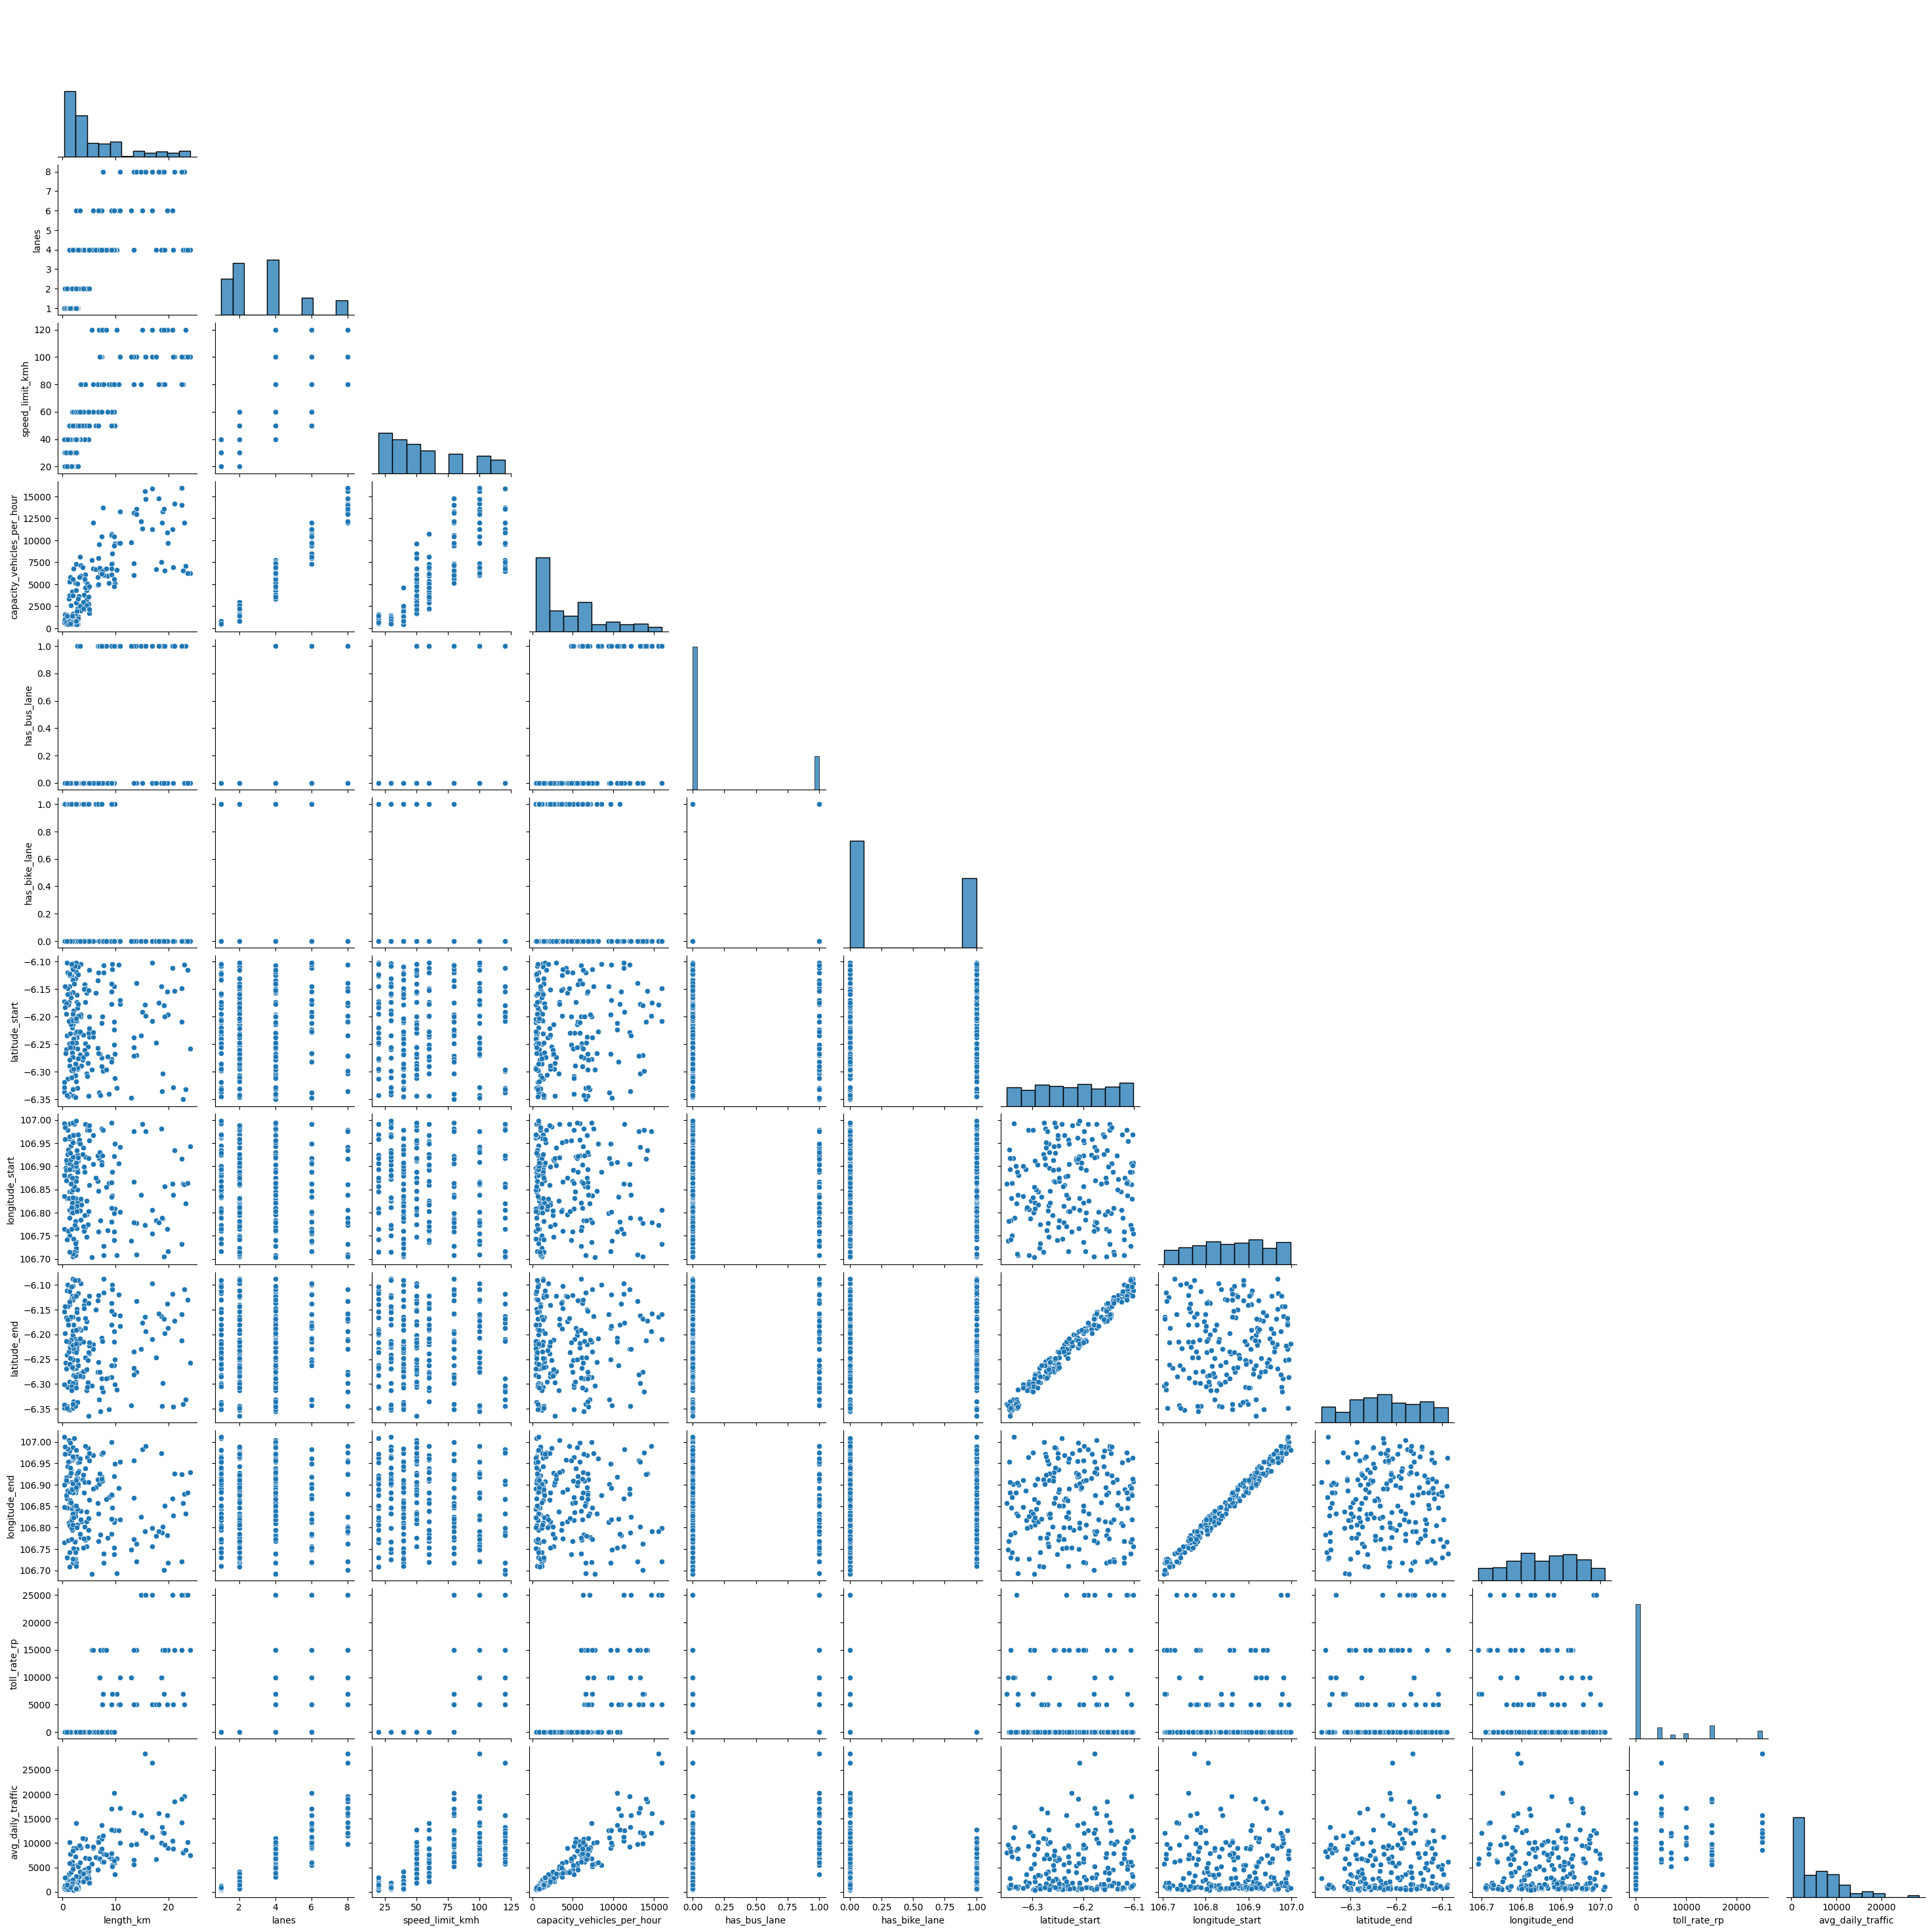

In [11]:
# Plotting only useful columns
grid = sns.pairplot(df,corner=True)

In [24]:
# For saving the plot
'''


grid.savefig('RoadNetwork.png', dpi=300, bbox_inches='tight')


'''
print('This plot gives us a rough idea of the data')

This plot gives us a rough idea of the data


<Axes: >

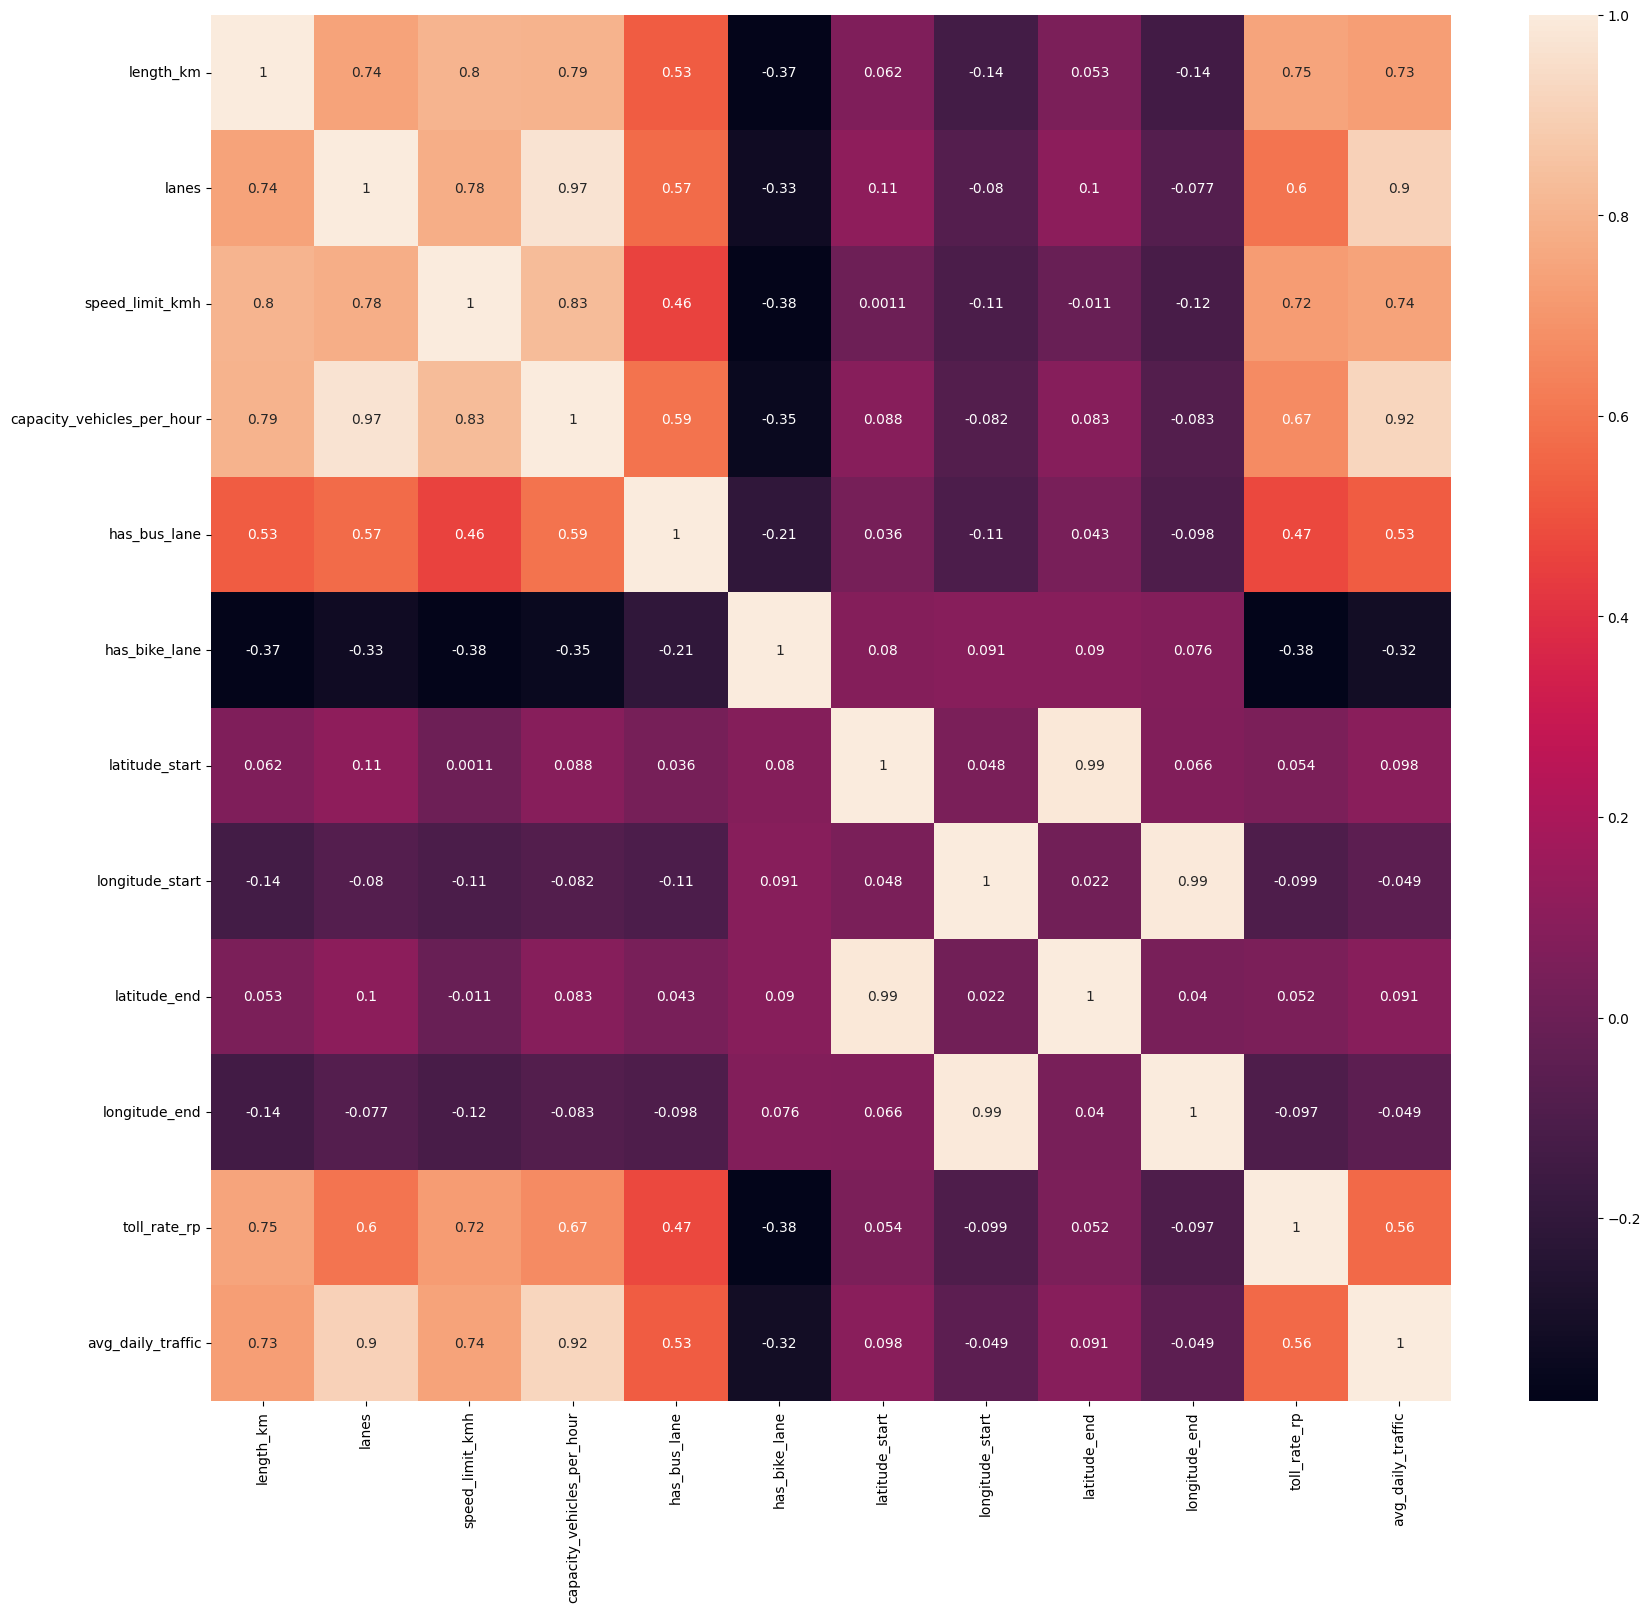

In [13]:
plt.figure(figsize=(20,18))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [18]:
for i in df.select_dtypes(include=['object', 'string']):
    counts = df[i].value_counts()
    print(counts)

road_id
RD-0001    1
RD-0138    1
RD-0128    1
RD-0129    1
RD-0130    1
          ..
RD-0070    1
RD-0071    1
RD-0072    1
RD-0073    1
RD-0200    1
Name: count, Length: 200, dtype: int64
road_name
Jl. Segment 1      1
Jl. Segment 138    1
Jl. Segment 128    1
Jl. Segment 129    1
Jl. Segment 130    1
                  ..
Jl. Segment 70     1
Jl. Segment 71     1
Jl. Segment 72     1
Jl. Segment 73     1
Jl. Segment 200    1
Name: count, Length: 200, dtype: int64
road_type
Jalan Tol           48
Jalan Lingkungan    46
Jalan Kolektor      44
Jalan Lokal         33
Jalan Arteri        29
Name: count, dtype: int64
surface_condition
Baik            106
Cukup            61
Rusak Ringan     23
Rusak Berat      10
Name: count, dtype: int64
last_maintenance_date
2022-08-10    3
2023-02-05    3
2022-12-21    2
2022-12-18    2
2023-12-23    2
             ..
2023-05-01    1
2022-09-16    1
2022-06-03    1
2023-07-30    1
2024-01-01    1
Name: count, Length: 173, dtype: int64
district
Mangga Du

In [14]:
df.columns

Index(['road_id', 'road_name', 'road_type', 'length_km', 'lanes',
       'speed_limit_kmh', 'capacity_vehicles_per_hour', 'has_bus_lane',
       'has_bike_lane', 'surface_condition', 'last_maintenance_date',
       'latitude_start', 'longitude_start', 'latitude_end', 'longitude_end',
       'district', 'toll_rate_rp', 'avg_daily_traffic'],
      dtype='object')

In [15]:
df.select_dtypes(include='number').columns

Index(['length_km', 'lanes', 'speed_limit_kmh', 'capacity_vehicles_per_hour',
       'has_bus_lane', 'has_bike_lane', 'latitude_start', 'longitude_start',
       'latitude_end', 'longitude_end', 'toll_rate_rp', 'avg_daily_traffic'],
      dtype='object')

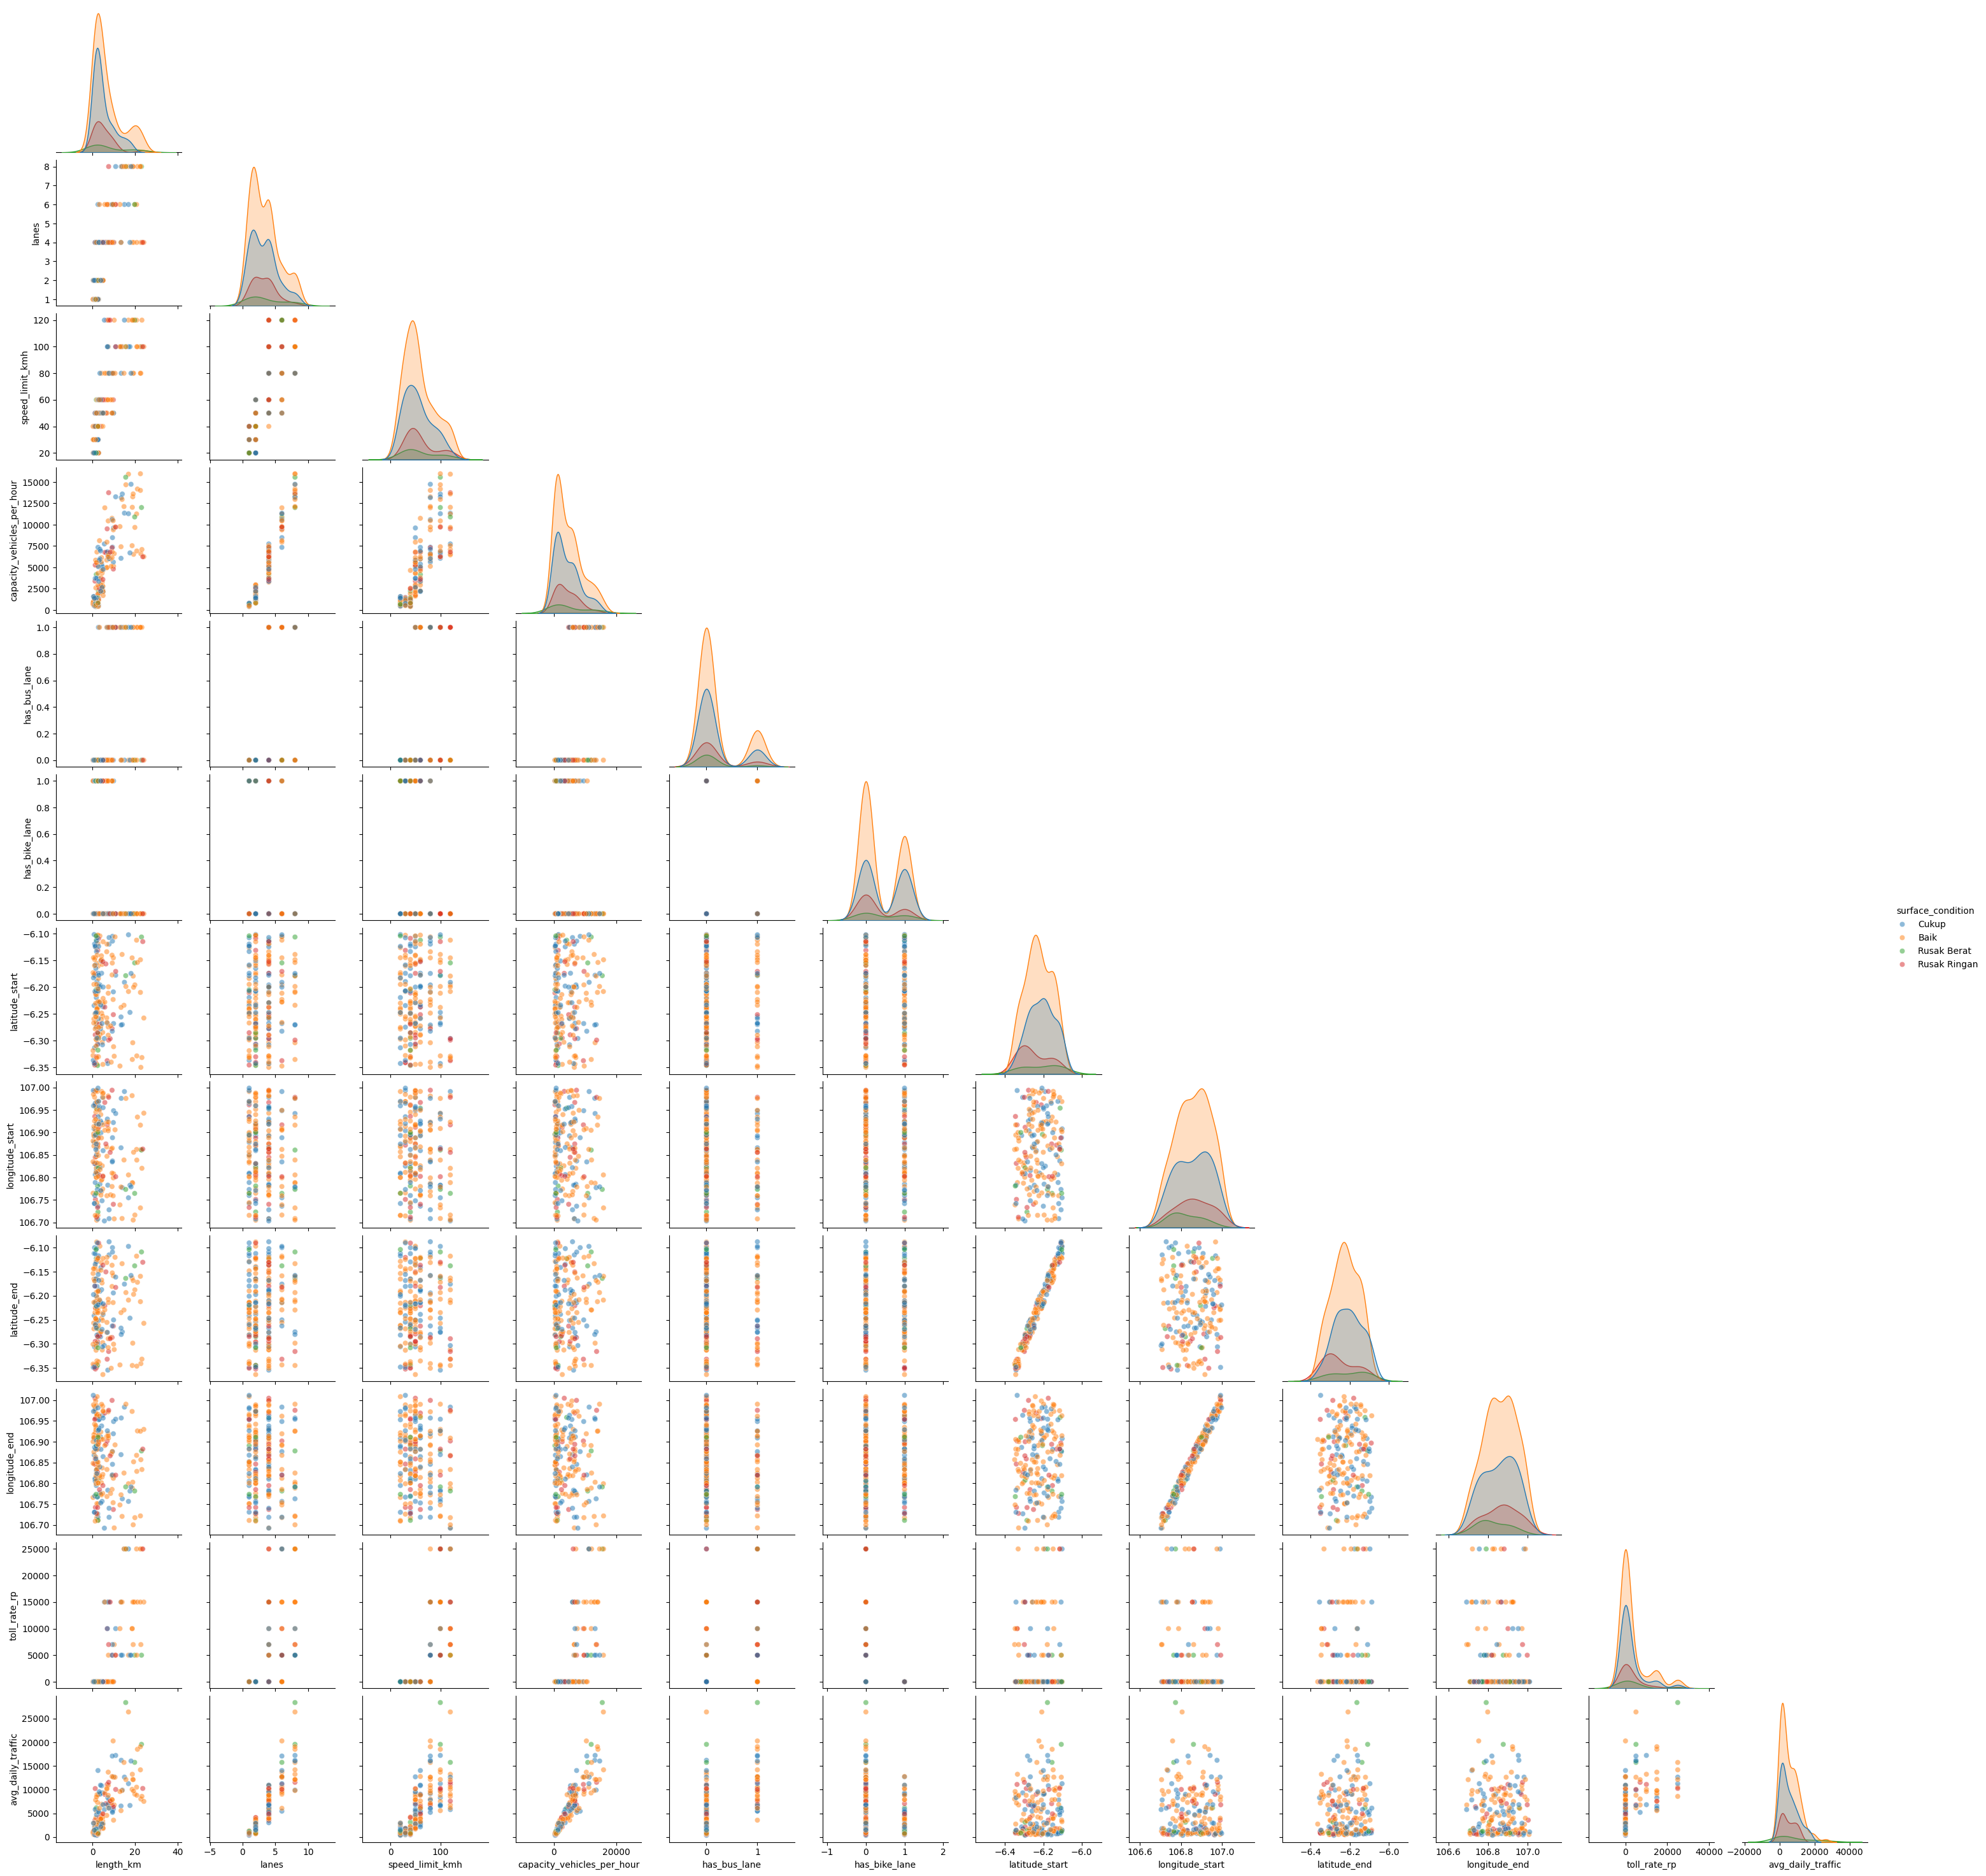

In [19]:
churnplot = sns.pairplot(
            df,
            vars=df.select_dtypes(include='number').columns,
            hue='surface_condition',
            plot_kws={'alpha':0.5},
            corner = True
            )

In [25]:
'''

churnplot.savefig('RoadNetworkCat.png', dpi=300, bbox_inches='tight')

'''

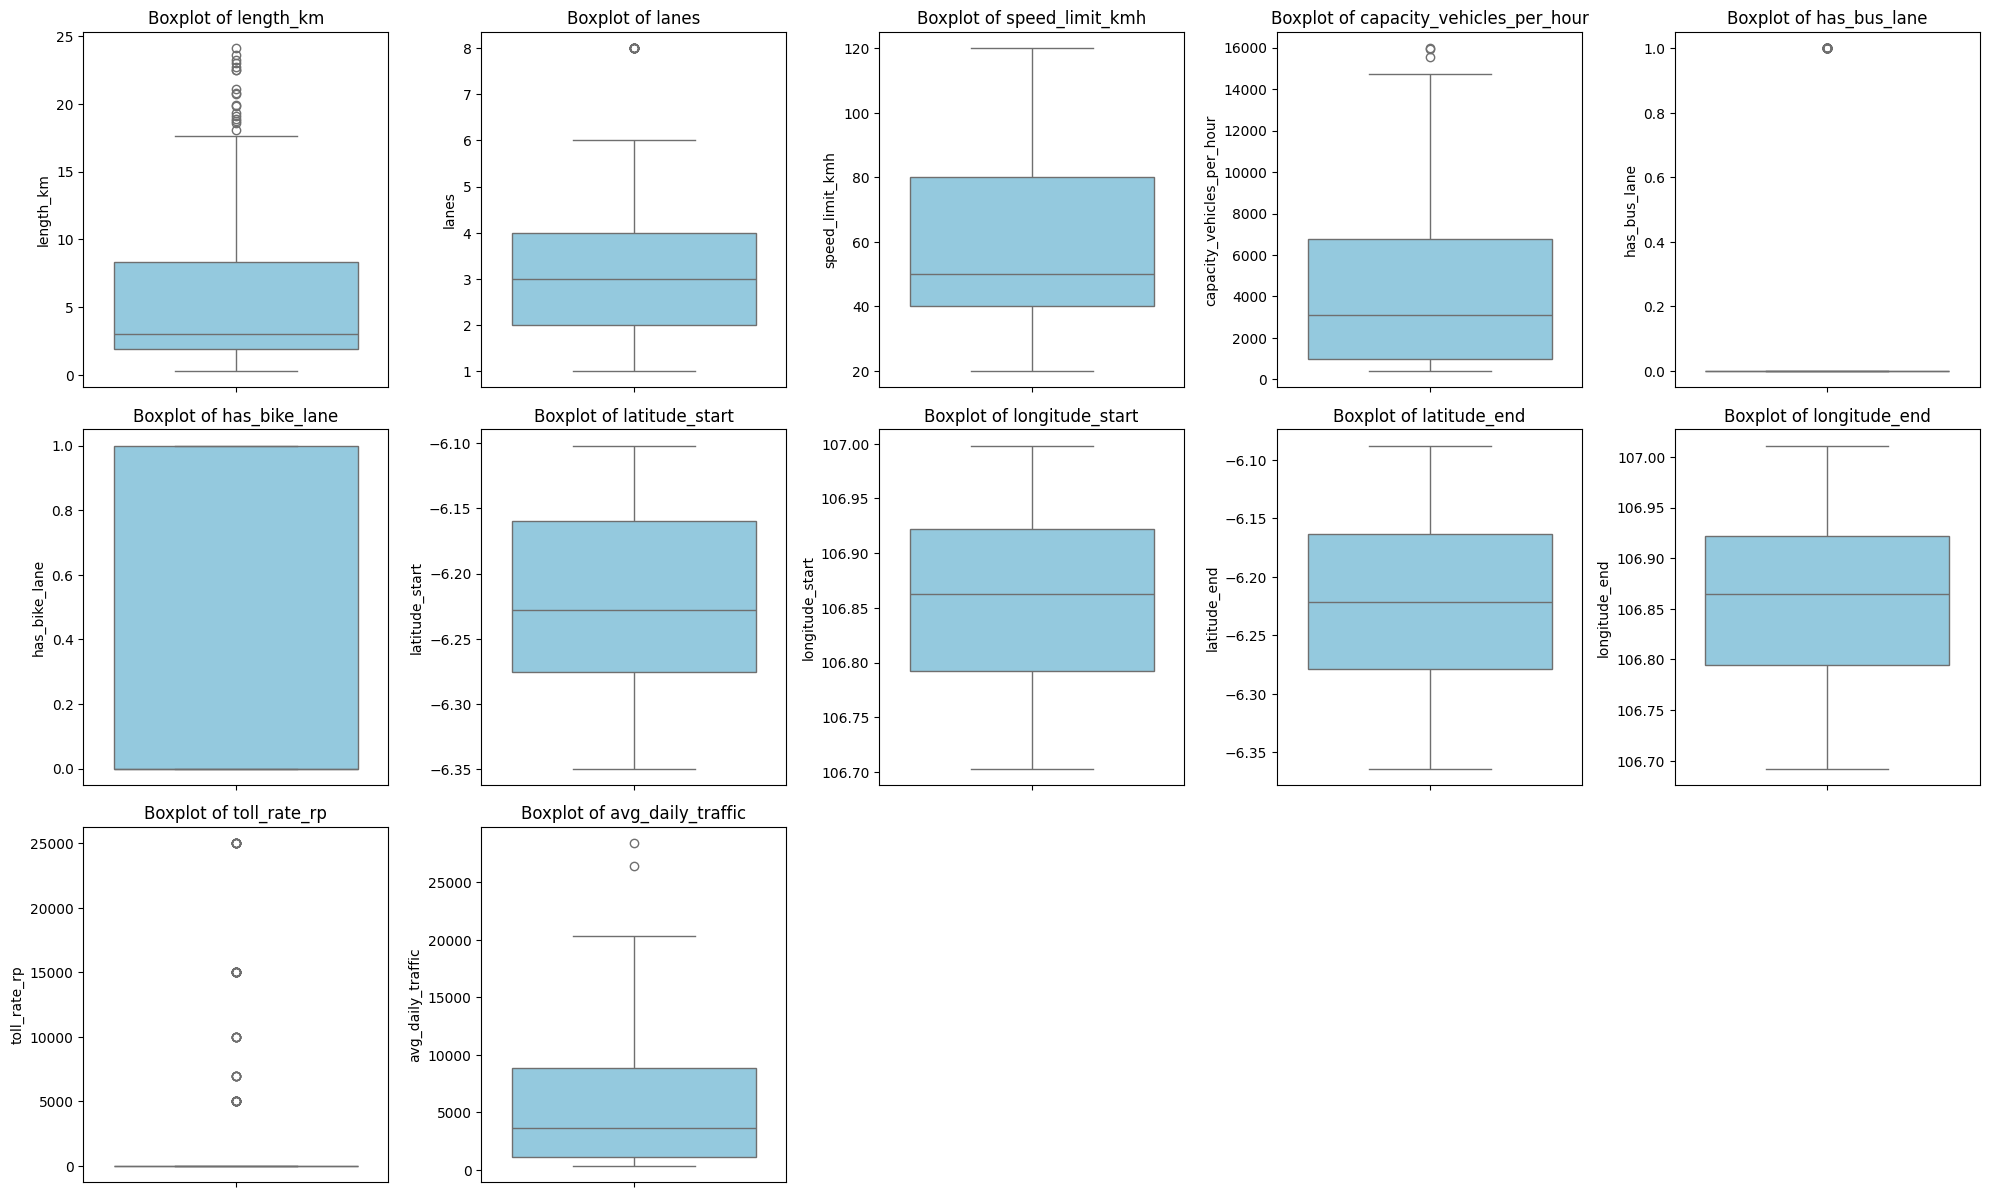

In [21]:
# Boxplot for outlier detection

numerical_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(20, 16))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4, 5, i)
    sns.boxplot(data=df, y=col, color='skyblue')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [22]:
for i in df.select_dtypes(include=['object', 'string']):
    counts = df[i].value_counts()
    print(counts)

road_id
RD-0001    1
RD-0138    1
RD-0128    1
RD-0129    1
RD-0130    1
          ..
RD-0070    1
RD-0071    1
RD-0072    1
RD-0073    1
RD-0200    1
Name: count, Length: 200, dtype: int64
road_name
Jl. Segment 1      1
Jl. Segment 138    1
Jl. Segment 128    1
Jl. Segment 129    1
Jl. Segment 130    1
                  ..
Jl. Segment 70     1
Jl. Segment 71     1
Jl. Segment 72     1
Jl. Segment 73     1
Jl. Segment 200    1
Name: count, Length: 200, dtype: int64
road_type
Jalan Tol           48
Jalan Lingkungan    46
Jalan Kolektor      44
Jalan Lokal         33
Jalan Arteri        29
Name: count, dtype: int64
surface_condition
Baik            106
Cukup            61
Rusak Ringan     23
Rusak Berat      10
Name: count, dtype: int64
last_maintenance_date
2022-08-10    3
2023-02-05    3
2022-12-21    2
2022-12-18    2
2023-12-23    2
             ..
2023-05-01    1
2022-09-16    1
2022-06-03    1
2023-07-30    1
2024-01-01    1
Name: count, Length: 173, dtype: int64
district
Mangga Du

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   road_id                     200 non-null    object 
 1   road_name                   200 non-null    object 
 2   road_type                   200 non-null    object 
 3   length_km                   200 non-null    float64
 4   lanes                       200 non-null    int64  
 5   speed_limit_kmh             200 non-null    int64  
 6   capacity_vehicles_per_hour  200 non-null    int64  
 7   has_bus_lane                200 non-null    int64  
 8   has_bike_lane               200 non-null    int64  
 9   surface_condition           200 non-null    object 
 10  last_maintenance_date       200 non-null    object 
 11  latitude_start              200 non-null    float64
 12  longitude_start             200 non-null    float64
 13  latitude_end                200 non